In [14]:
import os
import pandas as pd
import numpy as np
import anndata as ann
import spatialdm as sdm
from spatialdm.datasets import dataset
import spatialdm.plottings as pl
import time
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import scanpy as sc
from glob import glob
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")



slide_list = [os.path.basename(x) for x in glob("/data1/r20user3/shared_project/Hist2Cell/data/her2st/*") if os.path.isdir(x)]
selected_lr = list()

for slide in tqdm(slide_list):
    print(slide)
    
    spot_coord = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/spots.csv", index_col=0)[['X', 'Y']].values
    X = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/stdata.csv", index_col=0)
    cell_names = X.columns
    count = csr_matrix(X[cell_names].values)
    adata = ann.AnnData(count, obsm={"spatial": spot_coord})
    adata.var_names = cell_names
    adata.raw = adata
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)


    sdm.weight_matrix(adata, l=500, cutoff=0.2, single_cell=False, n_neighbors=160) 
    sdm.extract_lr(adata, 'human', min_cell=3)      # find overlapping LRs from CellChatDB


    start = time.time()
    sdm.spatialdm_global(adata, 1000, specified_ind=None, method='both', nproc=1)     # global Moran selection
    sdm.sig_pairs(adata, method='permutation', fdr=True, threshold=0.01)     # select significant pairs

    start = time.time()
    sdm.spatialdm_local(adata, n_perm=1000, method='both', specified_ind=None, nproc=1)     # local spot selection
    sdm.sig_spots(adata, method='permutation', fdr=False, threshold=0.1)     # significant local spots
    print("%.3f seconds" %(time.time()-start))

    adata.uns['selected_spots'].index
    
    selected_lr = selected_lr + list(adata.uns['selected_spots'].index)
    # break

  0%|          | 0/36 [00:00<?, ?it/s]

B4


  3%|▎         | 1/36 [00:36<21:03, 36.11s/it]

1.453 seconds
F3


  6%|▌         | 2/36 [02:34<48:01, 84.74s/it]

...

7.546 seconds
D4


 97%|█████████▋| 35/36 [34:31<00:57, 57.91s/it]

2.368 seconds
A2


100%|██████████| 36/36 [35:23<00:00, 58.97s/it]

1.451 seconds


In [15]:
selected_lr = set(selected_lr)

In [16]:
len(selected_lr)

373

In [17]:
selected_lr

{'ADM_CALCRL',
 'AGRN_DAG1',
 'AMH_AMHR2_ACVR1',
 'ANGPTL2_PIRB',
 'ANGPTL4_ITGA5_ITGB1',
 'ANGPTL4_ITGAV_ITGB3',
 'ANGPTL4_SDC1',
 'ANGPTL4_SDC2',
 'ANGPTL4_SDC3',
 'ANGPTL4_SDC4',
 'ANXA1_FPR1',
 'ANXA1_FPR2_LXA4',
 'AREG_EGFR_ERBB2',
 'BMP6_ACVR1_ACVR2A',
 'BMP7_ACVR1_ACVR2A',
 'BMP7_ACVR1_ACVR2B',
 'BMP7_ACVR1_BMPR2',
 'BMP7_BMPR1A_ACVR2B',
 'BMP7_BMPR1B_ACVR2B',
 'BMP7_BMPR1B_BMPR2',
 'BMP8A_ACVR1_ACVR2A',
 'BMP8A_ACVR1_ACVR2B',
 'BMP8A_ACVR1_BMPR2',
 'BMP8A_BMPR1A_BMPR2',
 'BMP8A_BMPR1B_BMPR2',
 'BTC_EGFR_ERBB2',
 'BTC_ERBB2_ERBB4',
 'C3_C3AR1',
 'C3_CR2',
 'C3_ITGAM_ITGB2',
 'C3_ITGAX_ITGB2',
 'CCL13_ACKR1',
 'CCL13_CCR1',
 'CCL19_CCR7',
 'CCL21_CCR7',
 'CCL28_CCR10',
 'CCL2_ACKR1',
 'CCL2_ACKR2',
 'CCL2_CCR2',
 'CCL4_CCR5',
 'CCL5_ACKR1',
 'CCL5_CCR1',
 'CCL5_CCR5',
 'CCL8_CCR1',
 'CCL8_CCR2',
 'CD22_PTPRC',
 'CD34_SELP',
 'CD70_CD27',
 'CD99_CD99',
 'CD99_PILRA',
 'CDH1_CDH1',
 'CDH1_ITGA1_ITGB1',
 'CDH1_ITGAE_ITGB7',
 'CDH1_KLRG1',
 'CDH2_CDH2',
 'CLCF1_CNTFR_LIFR',
 'CLEC2C_

In [8]:
import pickle

with open("/data1/r20user3/shared_project/Hist2Cell/code/data_preprocessing/selected_gene_lr_pairs/selected_pairs_fdr0.01.pkl", 'wb') as f:
    pickle.dump(selected_lr, f)

In [11]:
import pickle

selected_lr = pickle.load(open("/data1/r20user3/shared_project/Hist2Cell/code/data_preprocessing/selected_gene_lr_pairs/selected_pairs_fdr0.01.pkl", 'rb'))
selected_lr

[]

In [3]:
len(selected_lr)

373

In [14]:
from glob import glob
import os
import pandas as pd


slide_list = [os.path.basename(x) for x in glob("/data1/r20user3/shared_project/Hist2Cell/data/her2st/*") if os.path.isdir(x)]
selected_lr = list()
gene_set_list = list()

for slide in slide_list:
    # print(slide)
    X = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/stdata.csv", index_col=0)
    gene_set_list.append(list(X.columns))

In [25]:
# Find the intersection of all gene sets
intersection_set = set(gene_set_list[0])
for gene_set in gene_set_list[1:]:
    intersection_set = intersection_set.intersection(gene_set)
len(intersection_set)

11871

In [26]:
remove_lr_list = list()
for pair in selected_lr:
    for gene in pair.split('_'):
        if gene not in intersection_set:
            remove_lr_list.append(pair)
len(remove_lr_list)

112

In [28]:
common_selected_lr = [item for item in selected_lr if item not in remove_lr_list]
len(common_selected_lr)

272

In [29]:
length_list = list()
for pair in common_selected_lr:
    length_list.append(len(pair.split("_")))
set(length_list)

{2, 3}

In [30]:
spot_coord = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/spots.csv", index_col=0)[['X', 'Y']].values
X = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/stdata.csv", index_col=0)
cell_names = X.columns
count = csr_matrix(X[cell_names].values)
adata = ann.AnnData(count, obsm={"spatial": spot_coord})
adata.var_names = cell_names
adata.raw = adata
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
df = pd.DataFrame(adata.X.todense(), columns=cell_names)
df

,FO538757.1,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,MTCP1,VBP1,CLIC2,TMLHE,SPRY3,VAMP7,ZFY,PCDH11Y,USP9Y,UTY
0,0.0,0.933936,0.933936,0.933936,0.933936,0.0,0.933936,0.933936,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,1.235322,0.000000,0.000000,0.000000,0.0,1.235322,0.000000,0.000000,0.0,...,0.0,0.797392,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,1.012179,1.012179,0.000000,0.000000,0.0,1.504784,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.000000,1.414178,0.000000,0.000000,0.0,1.414178,0.000000,1.414178,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,2.124483,1.044558,1.044558,0.000000,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,1.544213,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320,0.0,1.452423,0.836980,0.000000,0.000000,0.0,1.086565,0.000000,0.503615,0.0,...,0.0,0.836980,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
321,0.0,1.323665,1.323665,0.000000,0.000000,0.0,2.226945,1.874005,0.000000,0.0,...,0.0,1.323665,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
322,0.0,1.308357,0.963194,0.000000,0.000000,0.0,0.963194,0.431794,0.431794,0.0,...,0.0,0.431794,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
323,0.0,0.576414,0.576414,0.000000,0.000000,0.0,0.576414,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [31]:
slide_list = [os.path.basename(x) for x in glob("/data1/r20user3/shared_project/Hist2Cell/data/her2st/*") if os.path.isdir(x)]
selected_lr = list()

for slide in slide_list:
    # print(slide)
    
    spot_coord = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/spots.csv", index_col=0)[['X', 'Y']].values
    X = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/stdata.csv", index_col=0)
    cell_names = X.columns
    count = csr_matrix(X[cell_names].values)
    adata = ann.AnnData(count, obsm={"spatial": spot_coord})
    adata.var_names = cell_names
    adata.raw = adata
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    df = pd.DataFrame(adata.X.todense(), columns=cell_names, index=X.index)
    
    X = df
        
    for pair in common_selected_lr:
        # print(pair)
        if len(pair.split("_")) == 2:
            X[pair] = X[pair.split("_")[0]] * X[pair.split("_")[1]]
        elif len(pair.split("_")) == 3:
            X[pair] = X[pair.split("_")[0]] * X[pair.split("_")[1]] * X[pair.split("_")[2]]
            
    X_lr = X[common_selected_lr]
    X_lr.to_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/selected_lr_fdr1e-2.csv")

In [1]:
# do some pca
from glob import glob
import os
import pandas as pd

slide_list = [os.path.basename(x) for x in glob("/data1/r20user3/shared_project/Hist2Cell/data/her2st/*") if os.path.isdir(x)]
selected_lr = list()

df_list = list()
for slide in slide_list:
    df = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/selected_lr.csv", index_col=0)
    
    new_index = df.index.map(lambda x: slide + "_" + str(x))
    df.rename(index=dict(zip(df.index, new_index)), inplace=True)
    
    df_list.append(df)

df_concat = pd.concat(df_list)
df_concat

,F11R_F11R,HLA-B_CD8A,HLA-C_CD8A,PTPRC_CD22,CD22_PTPRC,CDH1_CDH1,CDH1_ITGAE_ITGB7,SEMA4A_PLXNB2,COL4A5_ITGA9_ITGB1,FN1_ITGAV_ITGB1,...,CCL4_CCR5.1,HLA-E_CD8A.8,HLA-DPA1_CD4.10,HLA-DQA1_CD4.7,TNC_ITGAV_ITGB6.18,ANXA1_FPR1.1,MDK_LRP1,C3_ITGAX_ITGB2.25,C3_ITGAM_ITGB2.27,C3_C3AR1.8
spot_id,,,,,,,,,,,,,,,,,,,,,
B4_10x14,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
B4_10x15,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
B4_10x16,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
B4_10x17,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
B4_10x18,0.000000,0.0,0.0,0.0,0.0,0.027979,0.0,0.051942,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.051942,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2_9x26,0.700536,0.0,0.0,0.0,0.0,1.180624,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.253628,0.0,0.0,0.0,0.421516,0.000000,0.0,0.0
A2_9x27,3.511895,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
A2_9x28,0.927744,0.0,0.0,0.0,0.0,3.126449,0.0,1.703098,0.0,0.468516,...,0.0,0.0,0.000000,0.0,0.0,0.0,1.108246,0.080506,0.0,0.0


In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=0, n_init="auto").fit(df_concat.T)
kmeans

KMeans(n_clusters=10, n_init='auto', random_state=0)

In [10]:
cluster_label_list = list(kmeans.labels_)

In [11]:
for i in range(10):
    print(cluster_label_list.count(i))

1
249
1
6
1
3
6
2
1
2


In [12]:
cluster_label_list

[1,
 9,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 6,
 1,
 6,
 1,
 1,
 1,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 6,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 7,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 5,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 7,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 9,
 1,
 1,
 1,
 3,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 6,
 1,
 1,
 1,
 1,
 8,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 5,
 1,
 1,
 6,
 1,
 3,
 1,
 1,
 1,
 1,
 1,
 1,
 3,
 6,
 1,
 1,
 1,
 1,


In [13]:
cluster_df_list = list()
for label in range(10):
    indices = [i for i, value in enumerate(cluster_label_list) if value == label]
    columns_to_add = df_concat.columns[indices]
    df = pd.DataFrame(df_concat[columns_to_add].sum(axis=1))
    cluster_df_list.append(df)

In [14]:
cluster_merge_df = pd.concat(cluster_df_list, axis=1)
cluster_merge_df

,0,0,0,0,0,0,0,0,0,0
spot_id,,,,,,,,,,
B4_10x14,0.000000,0.431506,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
B4_10x15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
B4_10x16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
B4_10x17,0.725953,0.000000,0.000000,0.000000,0.000000,0.000000,0.725953,0.000000,0.0,0.000000
B4_10x18,0.027979,1.059586,0.051942,0.124408,0.000000,0.055959,0.460054,0.192857,0.0,0.051942
...,...,...,...,...,...,...,...,...,...,...
A2_9x26,1.180624,7.900166,0.731462,1.320947,0.253628,0.000000,3.559403,0.253628,0.0,0.800838
A2_9x27,4.959286,12.788975,3.565517,1.752090,0.000000,0.000000,9.550253,3.504180,0.0,6.857861
A2_9x28,2.086835,12.238419,4.200272,3.145802,1.224181,5.075048,9.285329,3.533197,0.0,7.382357


In [15]:
cluster_merge_df = (cluster_merge_df - cluster_merge_df.min()) / (cluster_merge_df.max() - cluster_merge_df.min())
cluster_merge_df

,0,0,0,0,0,0,0,0,0,0
spot_id,,,,,,,,,,
B4_10x14,0.000000,0.004109,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
B4_10x15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
B4_10x16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
B4_10x17,0.056997,0.000000,0.000000,0.000000,0.000000,0.000000,0.018476,0.000000,0.0,0.000000
B4_10x18,0.002197,0.010091,0.004373,0.004575,0.000000,0.002120,0.011709,0.008066,0.0,0.001966
...,...,...,...,...,...,...,...,...,...,...
A2_9x26,0.092695,0.075237,0.061578,0.048581,0.018700,0.000000,0.090590,0.010608,0.0,0.030316
A2_9x27,0.389370,0.121795,0.300165,0.064437,0.000000,0.000000,0.243061,0.146566,0.0,0.259607
A2_9x28,0.163844,0.116552,0.353602,0.115694,0.090259,0.192273,0.236319,0.147779,0.0,0.279463


In [16]:
# 生成新的列名
new_column_names = ['pattern' + str(i) for i in range(10)]

# 为DataFrame设置新的列名
cluster_merge_df.columns = new_column_names[:len(cluster_merge_df.columns)]
cluster_merge_df

,pattern0,pattern1,pattern2,pattern3,pattern4,pattern5,pattern6,pattern7,pattern8,pattern9
spot_id,,,,,,,,,,
B4_10x14,0.000000,0.004109,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
B4_10x15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
B4_10x16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
B4_10x17,0.056997,0.000000,0.000000,0.000000,0.000000,0.000000,0.018476,0.000000,0.0,0.000000
B4_10x18,0.002197,0.010091,0.004373,0.004575,0.000000,0.002120,0.011709,0.008066,0.0,0.001966
...,...,...,...,...,...,...,...,...,...,...
A2_9x26,0.092695,0.075237,0.061578,0.048581,0.018700,0.000000,0.090590,0.010608,0.0,0.030316
A2_9x27,0.389370,0.121795,0.300165,0.064437,0.000000,0.000000,0.243061,0.146566,0.0,0.259607
A2_9x28,0.163844,0.116552,0.353602,0.115694,0.090259,0.192273,0.236319,0.147779,0.0,0.279463


In [17]:
slide_list = [os.path.basename(x) for x in glob("/data1/r20user3/shared_project/Hist2Cell/data/her2st/*") if os.path.isdir(x)]

for slide in slide_list:
    selected_rows = cluster_merge_df[cluster_merge_df.index.str.startswith(slide)]
    selected_rows.index = selected_rows.index.str.replace(slide+'_', '')
    selected_rows.to_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/selected_lr_fdr1e-2_cluster10.csv")

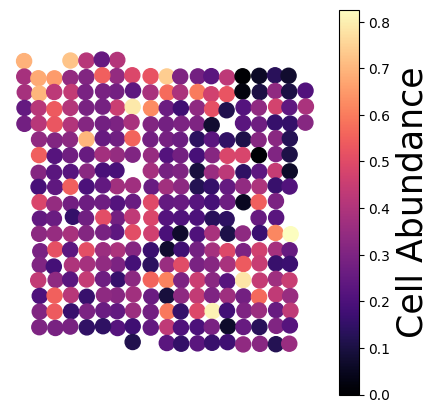

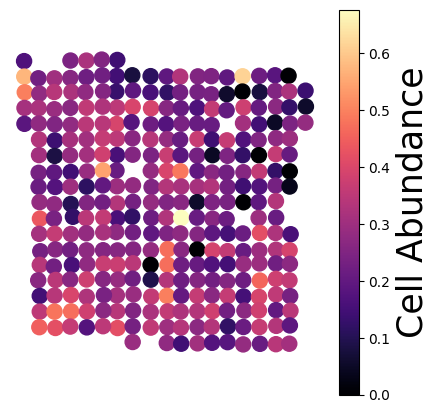

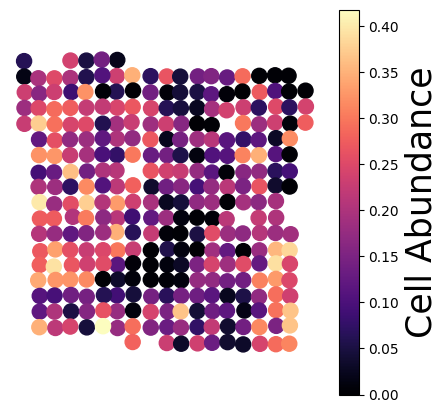

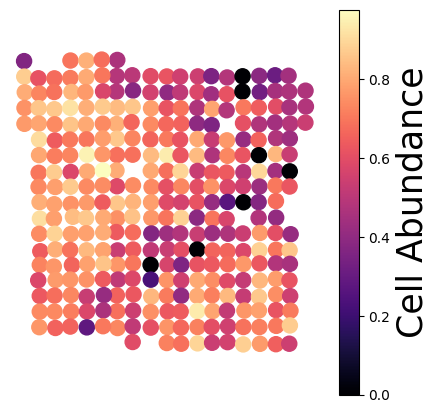

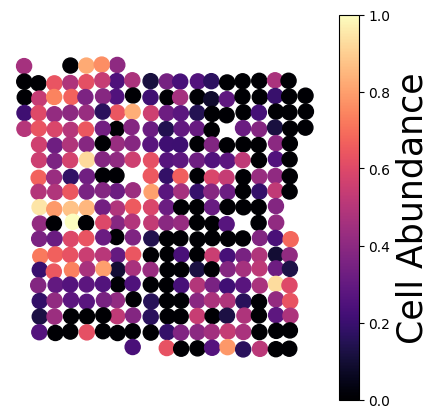

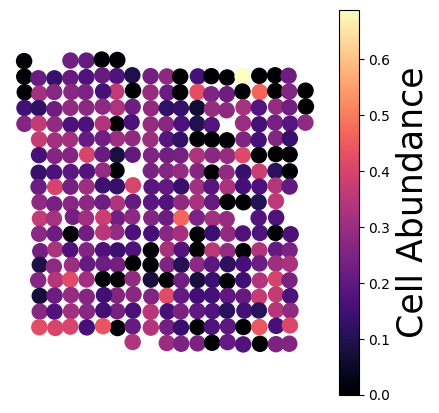

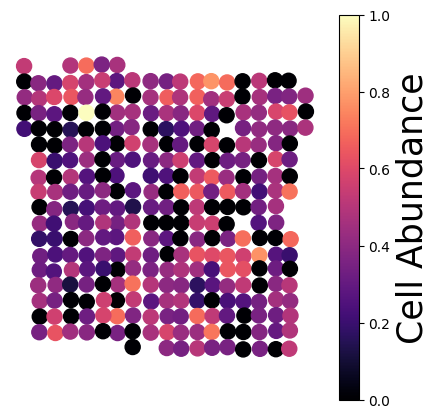

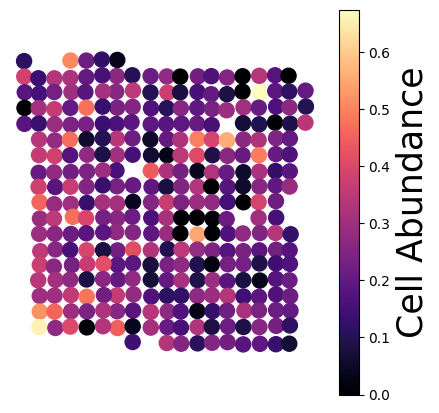

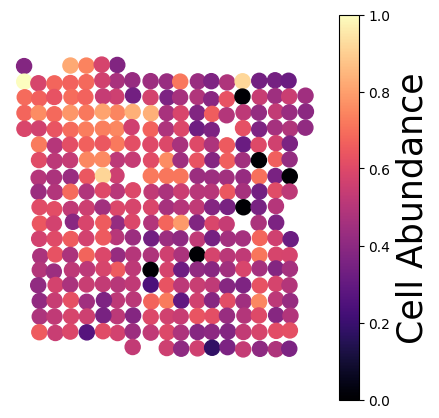

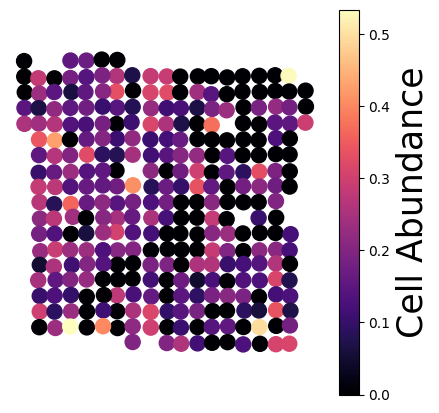

In [18]:
import matplotlib.pyplot as plt
import math
from IPython.core.pylabtools import figsize
import numpy as np


slide = "D1"
counts = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/selected_lr_cluster10.csv", index_col=0)
coordinates = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/spots.csv", index_col=0)
coordinates = coordinates.loc[counts.index]
counts = counts.values
coordinates = coordinates.values

X = coordinates[:, 0]
Y = coordinates[:, 1]

i = 0

for i in range(10):

    A = counts[:, i]

    # Calculate the minimum distance between points
    min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
    # Set the node size as a fraction of the minimum distance (e.g., 25%)
    node_size = min_distance * 0.50
    # set figure size
    figsize(5, 5)
    # Create a scatter plot with a color map
    plt.scatter(X, Y, c=A, cmap='magma', s=node_size)
    # Add a color bar with the spot values
    cbar = plt.colorbar()
    cbar.set_label('Cell Abundance', fontsize=25)
    # Add title
    # plt.suptitle(cell_names[i], fontsize=25, y=0.95)
    # Flip y-axis
    plt.gca().invert_yaxis()
    # Adjust the plot size to match the range of X and Y coordinates
    plt.xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
    plt.ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
    # Show the plot
    plt.axis('equal')
    plt.axis('off')
    
    plt.show()
    
    plt.close()

In [33]:
# do some pca

from sklearn.decomposition import PCA

# 创建一个PCA对象，设置要保留的主成分数量为10
pca = PCA(n_components=10)

# 使用fit_transform方法将DataFrame转换为新的低维DataFrame
df_pca = pd.DataFrame(pca.fit_transform(df_concat), index=df_concat.index)

from glob import glob
import os
import pandas as pd

slide_list = [os.path.basename(x) for x in glob("/data1/r20user3/shared_project/Hist2Cell/data/her2st/*") if os.path.isdir(x)]
selected_lr = list()

df_list = list()
for slide in slide_list:
    selected_rows = df_pca[df_pca.index.str.startswith(slide)]
    selected_rows.index = selected_rows.index.str.replace(slide+'_', '')
    selected_rows.to_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/selected_lr_fdr1e-2_pca10.csv")

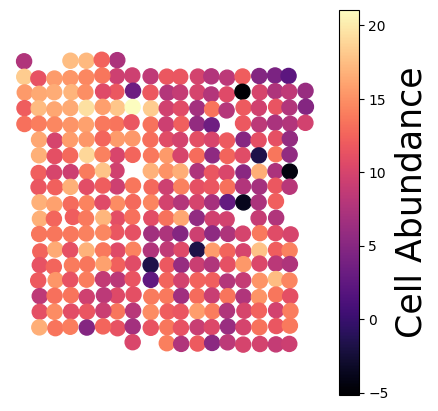

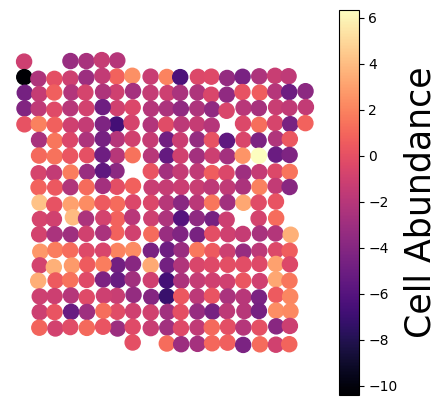

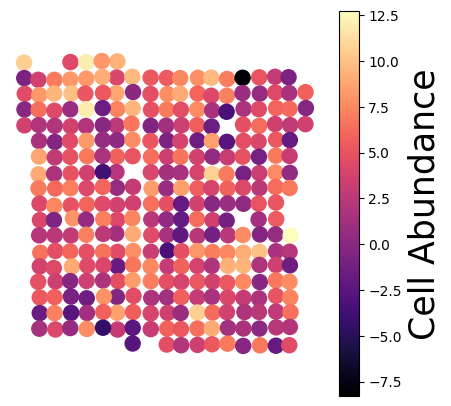

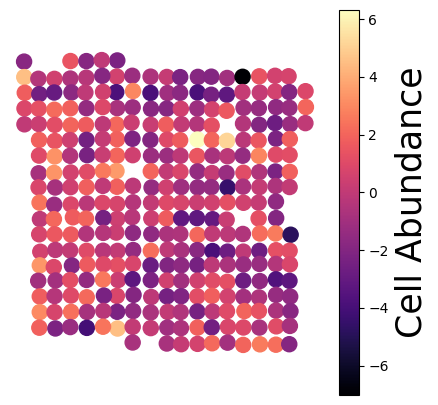

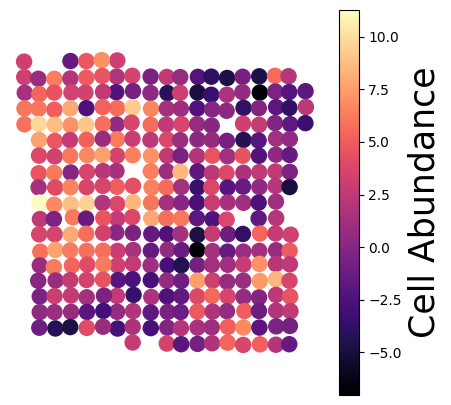

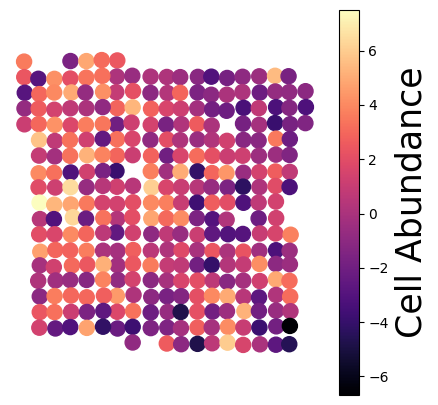

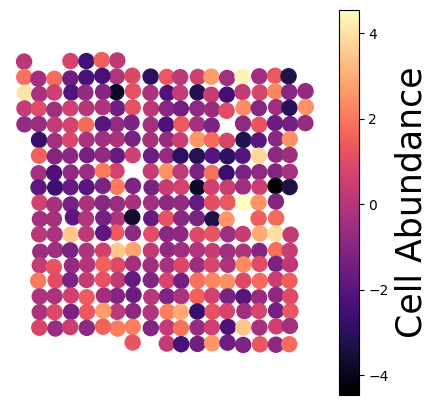

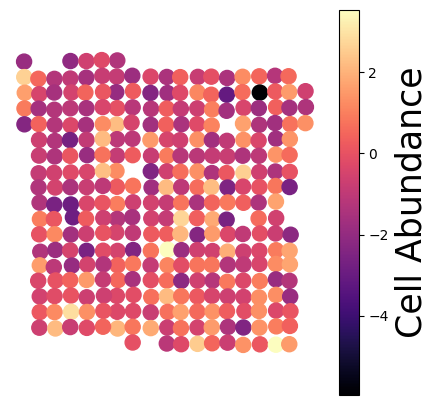

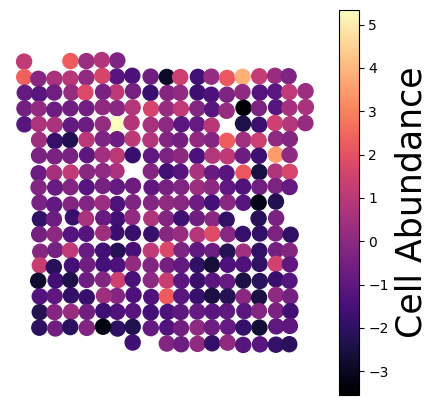

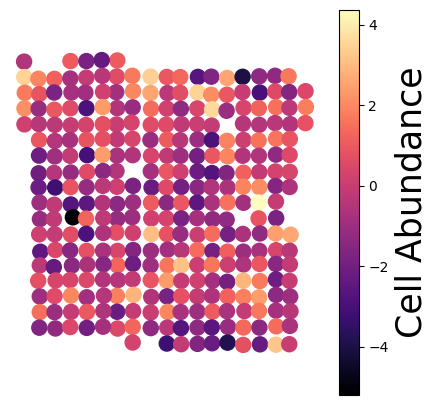

In [34]:
import matplotlib.pyplot as plt
import math
from IPython.core.pylabtools import figsize
import numpy as np


slide = "D1"
counts = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/selected_lr_fdr1e-2_pca10.csv", index_col=0)
coordinates = pd.read_csv("/data1/r20user3/shared_project/Hist2Cell/data/her2st/"+slide+"/spots.csv", index_col=0)
coordinates = coordinates.loc[counts.index]
counts = counts.values
coordinates = coordinates.values

X = coordinates[:, 0]
Y = coordinates[:, 1]

i = 0

for i in range(10):

    A = counts[:, i]

    # Calculate the minimum distance between points
    min_distance = np.min([math.sqrt((coordinates[i][0] - coordinates[j][0])**2 + (coordinates[i][1] - coordinates[j][1])**2) for i in range(len(coordinates)) for j in range(i+1, len(coordinates))])
    # Set the node size as a fraction of the minimum distance (e.g., 25%)
    node_size = min_distance * 0.50
    # set figure size
    figsize(5, 5)
    # Create a scatter plot with a color map
    plt.scatter(X, Y, c=A, cmap='magma', s=node_size)
    # Add a color bar with the spot values
    cbar = plt.colorbar()
    cbar.set_label('Cell Abundance', fontsize=25)
    # Add title
    # plt.suptitle(cell_names[i], fontsize=25, y=0.95)
    # Flip y-axis
    plt.gca().invert_yaxis()
    # Adjust the plot size to match the range of X and Y coordinates
    plt.xlim(min(coordinates[:, 0]), max(coordinates[:, 0]))
    plt.ylim(max(coordinates[:, 1]), min(coordinates[:, 1]))
    # Show the plot
    plt.axis('equal')
    plt.axis('off')
    
    plt.show()
    
    plt.close()
        
    # if i > 10:
    #     break